# 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# 2. Load Dataset

In [2]:
df = pd.read_csv("../data/nutrients_csvfile.csv")
df.head()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,t,t,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products


Dataset berisi informasi kandungan nutrisi dari berbagai jenis makanan. Ditemukan beberapa nilai non-numerik seperti `t` (trace amount) pada beberapa kolom yang perlu ditangani sebelum analisis dilakukan.

# 3. Data Understanding

## 3.1. Ukuran Dataset

In [3]:
df.shape

(335, 10)

Dataset terdiri dari 335 baris dan 10 kolom yang mencakup nama makanan, ukuran porsi, berat, dan kandungan nutrisi seperti kalori, protein, lemak, serat, serta karbohidrat.

## 3.2. Nama Kolom

In [4]:
df.columns.tolist()

['Food',
 'Measure',
 'Grams',
 'Calories',
 'Protein',
 'Fat',
 'Sat.Fat',
 'Fiber',
 'Carbs',
 'Category']

## 3.3. Tipe Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Food      335 non-null    object
 1   Measure   335 non-null    object
 2   Grams     335 non-null    object
 3   Calories  334 non-null    object
 4   Protein   335 non-null    object
 5   Fat       335 non-null    object
 6   Sat.Fat   333 non-null    object
 7   Fiber     335 non-null    object
 8   Carbs     335 non-null    object
 9   Category  335 non-null    object
dtypes: object(10)
memory usage: 26.3+ KB


Terdapat kombinasi fitur numerik dan kategorikal. Beberapa kolom bertipe `object` meskipun seharusnya numerik, disebabkan adanya nilai non-numerik seperti `t`.

# 4. Data Cleaning

## 4.1. Cek Missing Value

In [6]:
df.isnull().sum()

Food        0
Measure     0
Grams       0
Calories    1
Protein     0
Fat         0
Sat.Fat     2
Fiber       0
Carbs       0
Category    0
dtype: int64

## 4.2. Cek Duplikasi

In [7]:
df.duplicated().sum()

np.int64(0)

## 4.3. Bersihkan Nilai 't' (Trace Amount)

In [8]:
df.replace('t', 0, inplace=True)

Nilai `t` merepresentasikan *trace amount* — kandungan yang sangat kecil mendekati nol. Nilai ini diganti dengan 0 agar kolom dapat dikonversi ke tipe numerik.

## 4.4. Konversi Kolom Numerik

In [9]:
numeric_columns = ['Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat', 'Fiber', 'Carbs']

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## 4.5. Cek Missing Value Setelah Konversi

In [10]:
df.isnull().sum()

Food        0
Measure     0
Grams       1
Calories    5
Protein     0
Fat         1
Sat.Fat     2
Fiber       1
Carbs       0
Category    0
dtype: int64

## 4.6. Hapus Baris dengan Missing Value

In [11]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Jumlah data setelah cleaning: {len(df)}')

Jumlah data setelah cleaning: 326


## 4.7. Perbaiki Nilai Negatif pada Protein

In [12]:
df[df['Protein'] < 0]

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
135,French-fried,10 pieces,60.0,155.0,-1,7.0,3.0,0.4,20.0,Vegetables R-Z


In [13]:
protein_median = df['Protein'].median()
df.loc[df['Protein'] < 0, 'Protein'] = protein_median
print(f'Nilai minimum Protein setelah perbaikan: {df["Protein"].min()}')

Nilai minimum Protein setelah perbaikan: 0


Ditemukan satu baris dengan nilai protein negatif yang tidak valid. Nilai tersebut diganti dengan median protein untuk mempertahankan distribusi data.

# 5. Exploratory Data Analysis (EDA)

## 5.1. Statistik Deskriptif

In [14]:
df.describe()

,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
count,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000,326.000000
mean,138.033742,179.861963,8.156442,8.361963,6.438650,2.181933,23.813804
std,118.690219,155.339061,17.162304,19.788208,18.676211,15.861996,32.306350
min,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,57.750000,75.000000,1.000000,0.000000,0.000000,0.000000,3.000000
50%,108.000000,130.000000,3.000000,1.000000,0.000000,0.200000,14.000000
75%,200.000000,245.000000,12.000000,10.000000,7.000000,1.000000,30.000000
max,984.000000,992.000000,232.000000,233.000000,234.000000,235.000000,236.000000


Distribusi nutrisi antar makanan sangat bervariasi. Standar deviasi yang tinggi pada fitur Calories, Fat, dan Carbs menunjukkan adanya keragaman besar dalam dataset, sekaligus mengindikasikan potensi outlier yang perlu ditangani.

## 5.2. Distribusi Nutrisi

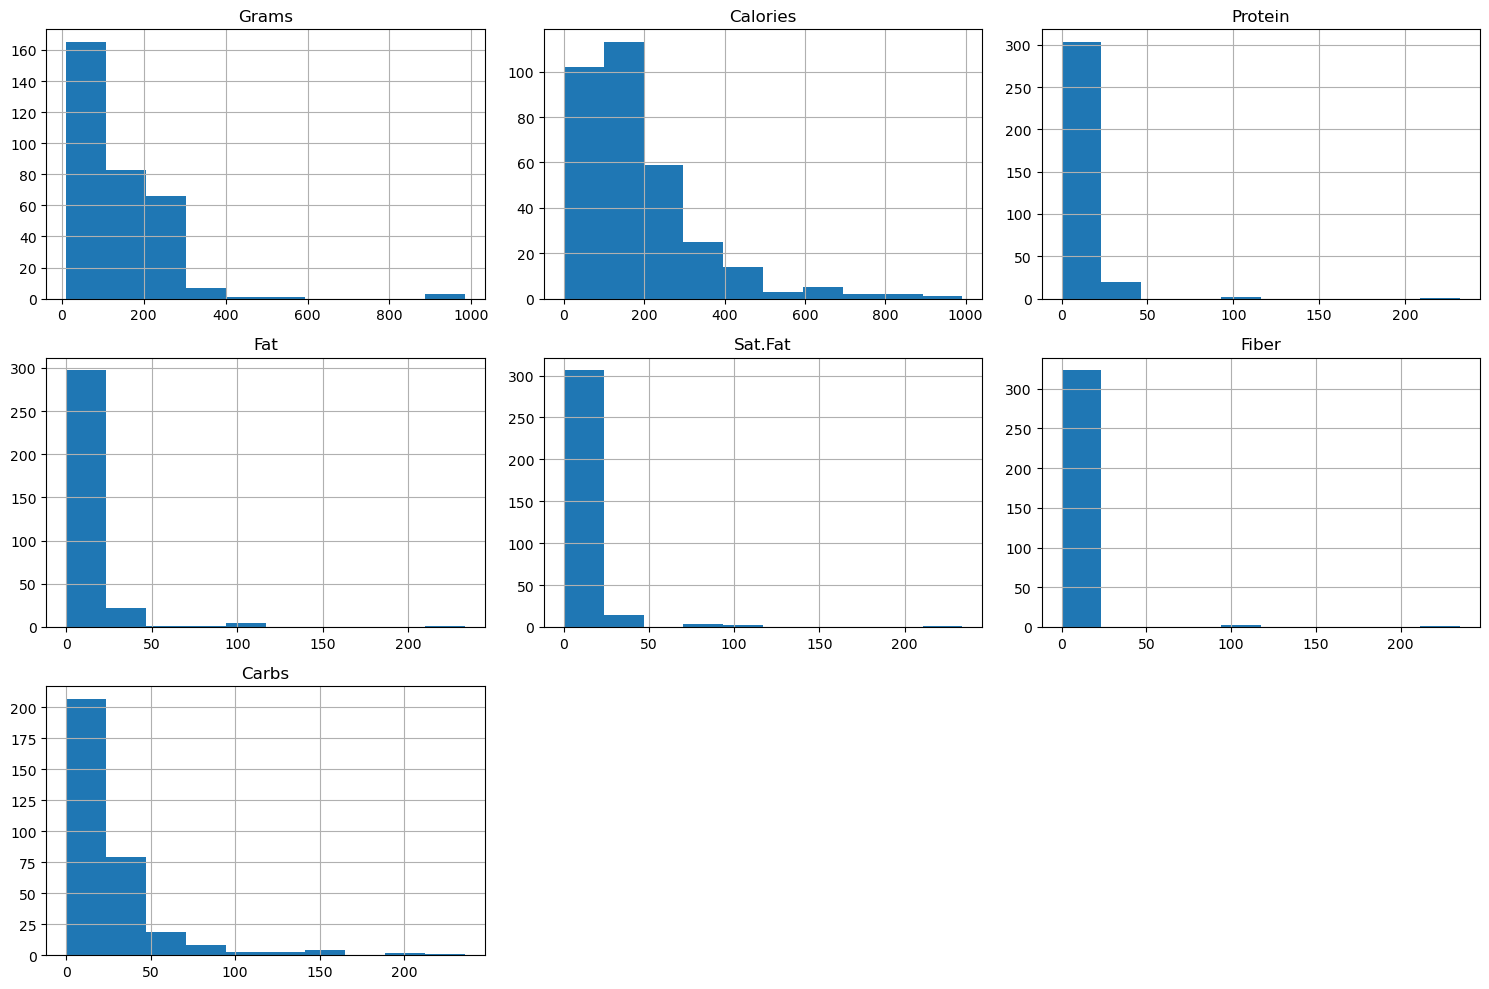

In [15]:
df[numeric_columns].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

Sebagian besar fitur memiliki distribusi miring ke kanan (*right-skewed*), yang menunjukkan mayoritas makanan memiliki kandungan nutrisi rendah hingga sedang dengan sejumlah makanan bernilai sangat tinggi.

## 5.3. Korelasi Antar Nutrisi

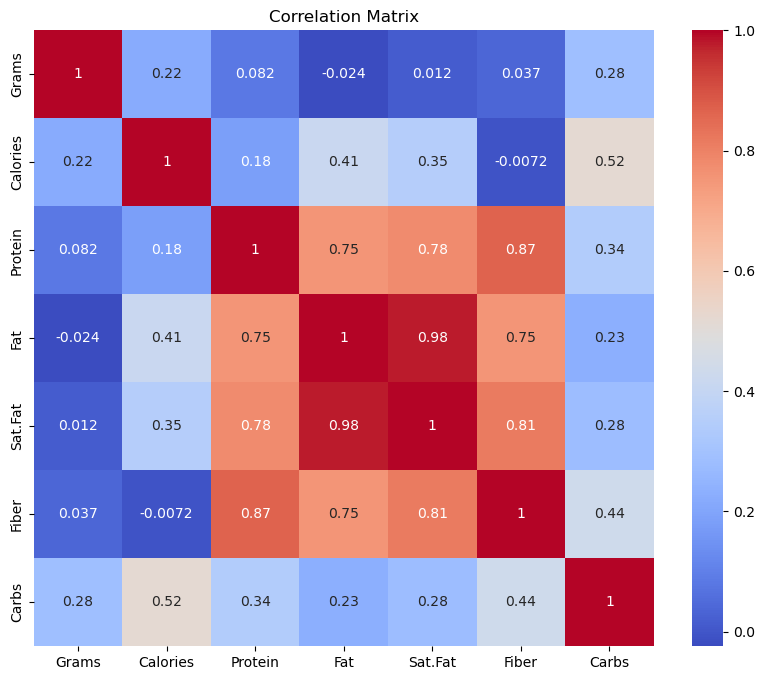

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Fat dan Sat.Fat memiliki korelasi sangat tinggi (>0.95), menunjukkan bahwa makanan berlemak tinggi hampir selalu mengandung lemak jenuh tinggi. Calories berkorelasi sedang dengan Carbs dan Fat.

## 5.4. Distribusi Kategori Makanan

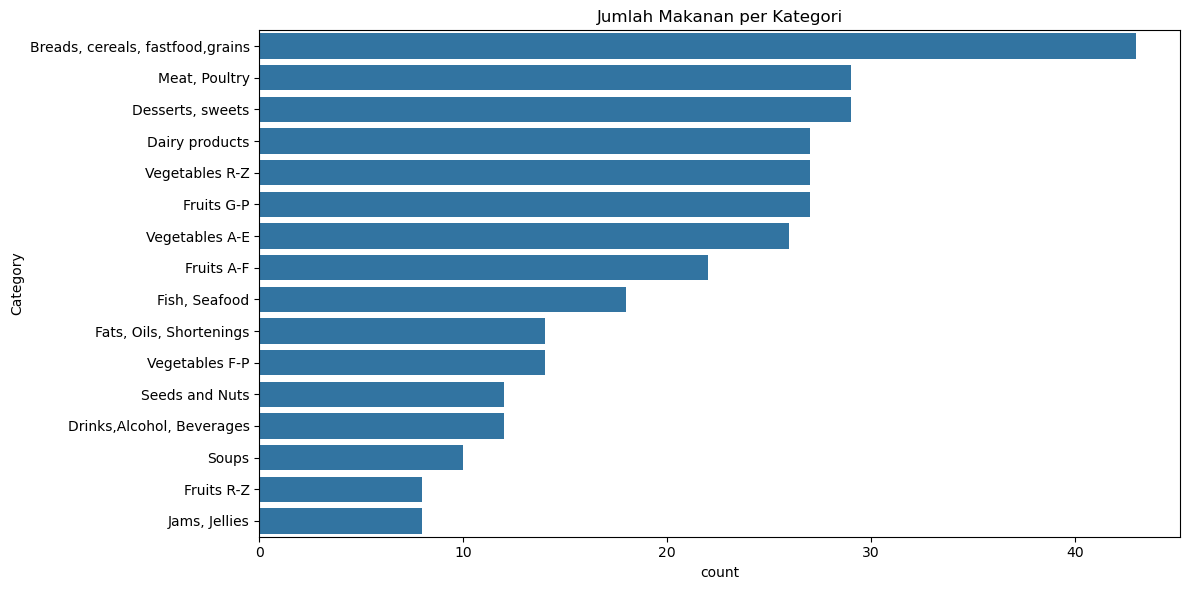

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index)
plt.title('Jumlah Makanan per Kategori')
plt.tight_layout()
plt.show()

## 5.5. Boxplot Outlier (Sebelum Penanganan)

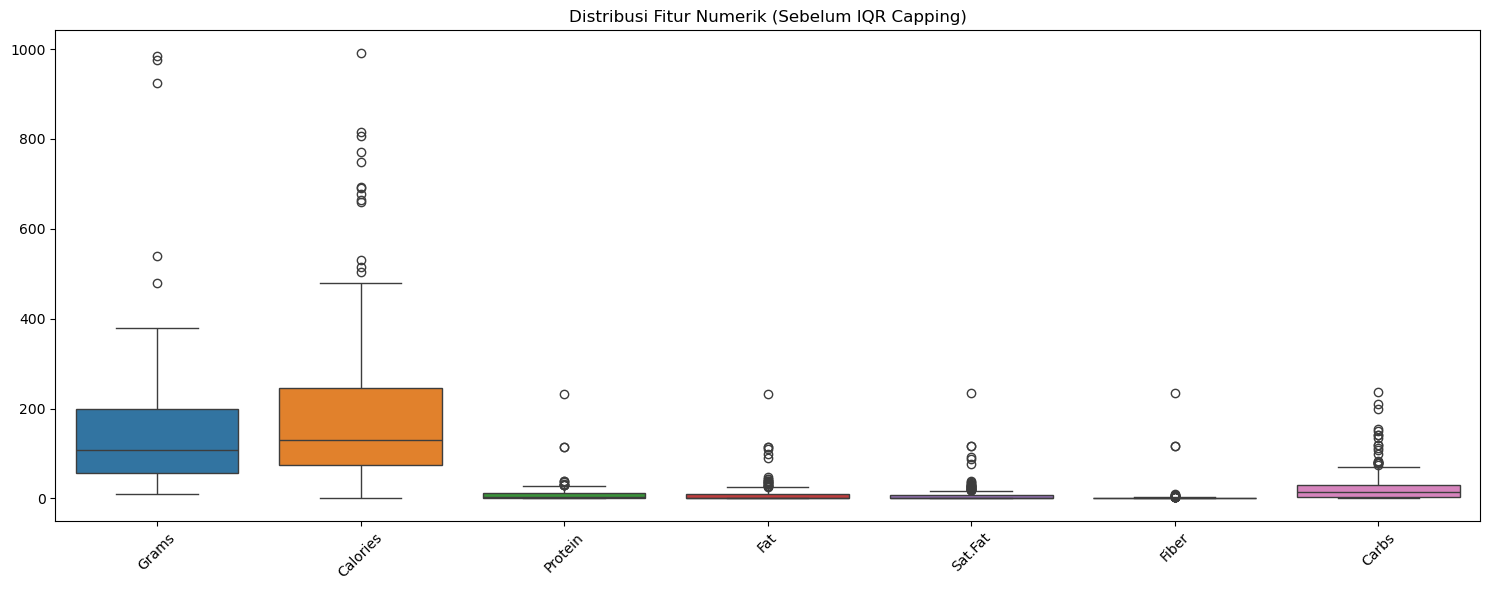

In [18]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[numeric_columns])
plt.xticks(rotation=45)
plt.title('Distribusi Fitur Numerik (Sebelum IQR Capping)')
plt.tight_layout()
plt.show()

Hampir seluruh fitur numerik memiliki outlier yang signifikan, terutama pada Protein, Fat, dan Sat.Fat. Outlier perlu ditangani sebelum proses scaling dan clustering agar tidak mendistorsi hasil pengelompokan.

## 5.6. Penanganan Outlier dengan IQR Capping

In [19]:
features = ['Calories', 'Protein', 'Fat', 'Sat.Fat', 'Fiber', 'Carbs']

df_clean = df.copy()

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print('Selesai. Jumlah data tetap:', len(df_clean))

Selesai. Jumlah data tetap: 326


## 5.7. Boxplot Setelah IQR Capping

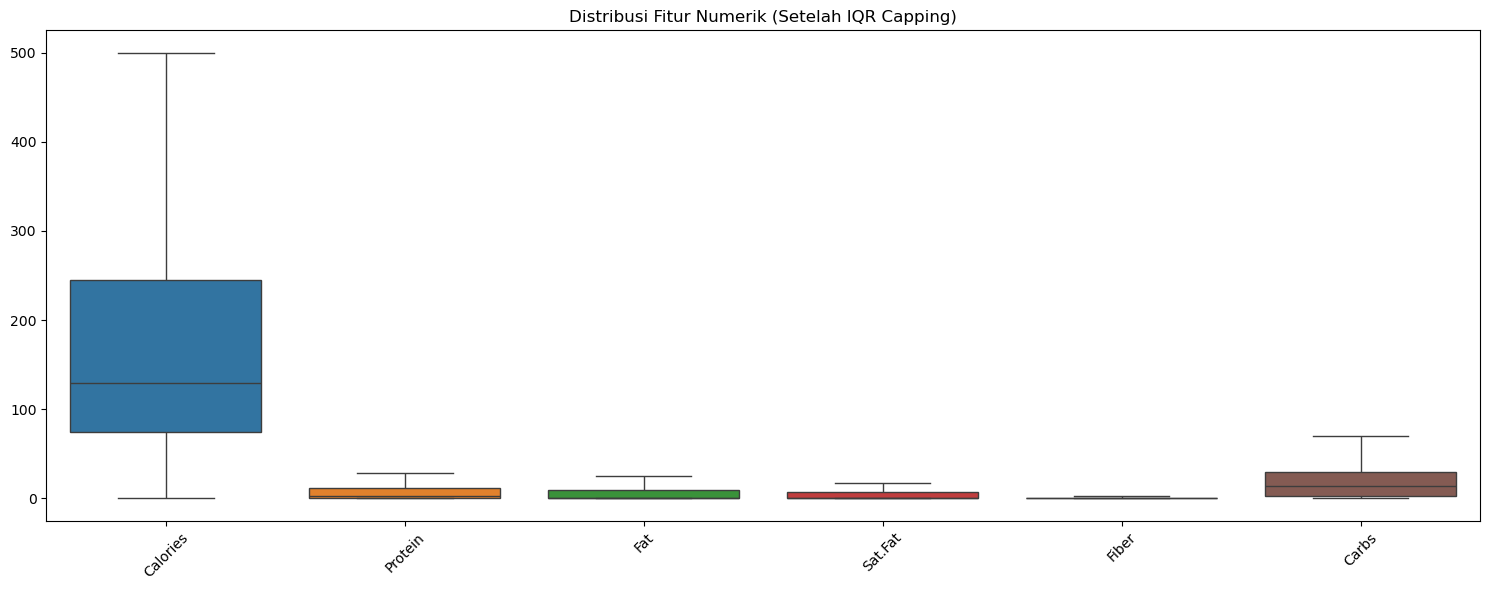

In [20]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_clean[features])
plt.xticks(rotation=45)
plt.title('Distribusi Fitur Numerik (Setelah IQR Capping)')
plt.tight_layout()
plt.show()

Setelah IQR Capping, nilai ekstrem pada setiap fitur di-*clip* ke batas atas dan bawah IQR. Data tidak berkurang karena metode ini mengganti nilai ekstrem dengan batas wajar, bukan menghapus baris. Distribusi menjadi lebih merata dan siap untuk proses clustering.

# 6. Feature Selection

## 6.1. Fitur yang Digunakan

In [21]:
features = ['Calories', 'Protein', 'Fat', 'Sat.Fat', 'Fiber', 'Carbs']

X = df_clean[features]
X.head()

,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
0,500.0,28.5,25.0,17.5,0.0,48.0
1,360.0,28.5,0.0,0.0,0.0,52.0
2,127.0,9.0,5.0,4.0,0.0,13.0
3,345.0,16.0,20.0,17.5,0.0,24.0
4,500.0,27.0,25.0,17.5,0.0,39.0


Dipilih enam fitur numerik yang merepresentasikan kandungan makronutrien utama. Fitur kategorikal seperti Food, Measure, dan Category tidak digunakan dalam clustering namun tetap disimpan untuk keperluan interpretasi hasil.

# 7. Feature Scaling

## 7.1. Implementasi StandardScaler

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()

,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
0,2.536316,2.620913,2.384665,2.313876,-0.786176,1.351714
1,1.453763,2.620913,-0.751027,-0.682529,-0.786176,1.548367
2,-0.347916,0.255449,-0.123889,0.002364,-0.786176,-0.368995
3,1.337775,1.104590,1.757527,2.313876,-0.786176,0.171799
4,2.536316,2.438955,2.384665,2.313876,-0.786176,0.909246


## 7.2. Verifikasi Hasil Scaling

In [23]:
X_scaled.describe().round(4)

,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
count,326.0000,326.0000,326.0000,326.0000,326.0000,326.0000
mean,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000
std,1.0015,1.0015,1.0015,1.0015,1.0015,1.0015
min,-1.3299,-0.8363,-0.7510,-0.6825,-0.7862,-1.0081
25%,-0.7500,-0.7150,-0.7510,-0.6825,-0.7862,-0.8606
50%,-0.3247,-0.4724,-0.6256,-0.6825,-0.5403,-0.3198
75%,0.5645,0.6194,0.5032,0.5160,0.4430,0.4668
max,2.5363,2.6209,2.3847,2.3139,2.2867,2.4579


## 7.3. Boxplot Setelah Scaling

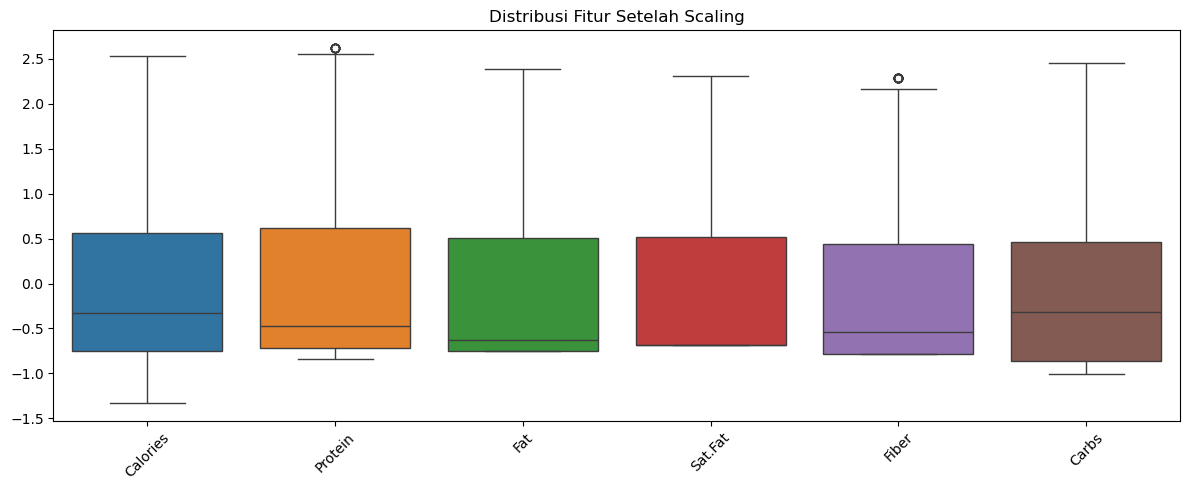

In [24]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=X_scaled)
plt.xticks(rotation=45)
plt.title('Distribusi Fitur Setelah Scaling')
plt.tight_layout()
plt.show()

Setelah StandardScaler diterapkan pada data yang telah di-*cap*, seluruh fitur memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Outlier yang tersisa jauh lebih terkendali dibanding sebelum IQR Capping, sehingga data siap digunakan dalam proses clustering.

# 8. Menentukan Jumlah Cluster Optimal

## 8.1. Elbow Method

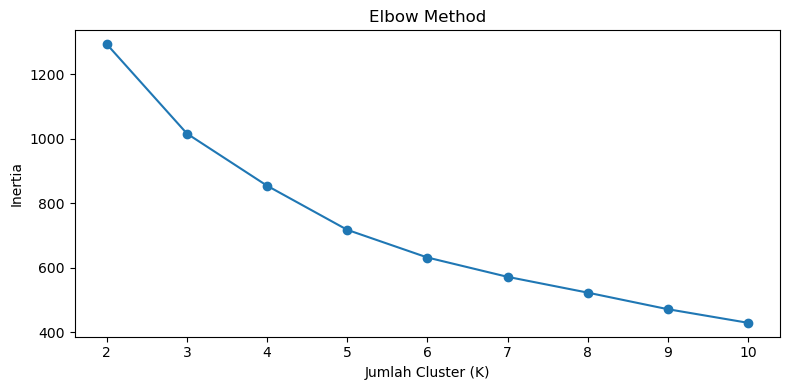

In [25]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## 8.2. Silhouette Score per K

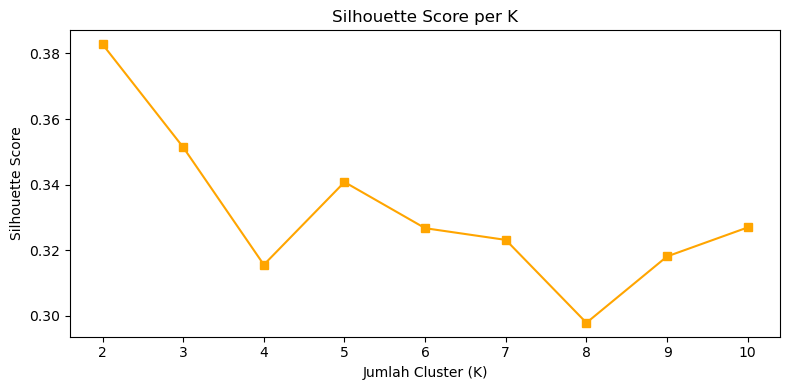

In [26]:
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker='s', color='orange')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per K')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## 8.3. Tabel Perbandingan K

In [27]:
comparison = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertia,
    'Silhouette Score': [round(s, 4) for s in sil_scores]
})
comparison

,K,Inertia,Silhouette Score
0,2,1292.512619,0.3828
1,3,1015.424369,0.3514
2,4,853.723721,0.3155
3,5,717.019161,0.3408
4,6,631.222979,0.3267
5,7,571.282181,0.3231
6,8,522.321544,0.2978
7,9,470.910815,0.3181
8,10,428.742118,0.3269


Berdasarkan Elbow Method, penurunan inertia mulai melambat secara signifikan di sekitar K=4. Silhouette Score pada K=4 juga menunjukkan nilai yang baik dan stabil dibanding K yang lebih besar. Dengan mempertimbangkan kedua metode tersebut, **K=4 dipilih** sebagai jumlah cluster optimal yang memberikan keseimbangan antara kualitas pengelompokan dan interpretabilitas hasil.

# 9. Implementasi K-Means Clustering

## 9.1. Training K-Means dengan K=4

In [28]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## 9.2. Assign Label Cluster ke DataFrame

In [29]:
df_result = df_clean.copy()
df_result['Cluster'] = kmeans.labels_

df_result[['Food', 'Category', 'Cluster'] + features].head(10)

,Food,Category,Cluster,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
0,Cows' milk,Dairy products,1,500.0,28.5,25.0,17.5,0.0,48.0
1,Milk skim,Dairy products,2,360.0,28.5,0.0,0.0,0.0,52.0
2,Buttermilk,Dairy products,3,127.0,9.0,5.0,4.0,0.0,13.0
3,"Evaporated, undiluted",Dairy products,1,345.0,16.0,20.0,17.5,0.0,24.0
4,Powdered milk,Dairy products,1,500.0,27.0,25.0,17.5,0.0,39.0
5,"skim, instant",Dairy products,2,290.0,28.5,0.0,0.0,0.0,42.0
6,"skim, non-instant",Dairy products,2,290.0,28.5,0.0,0.0,1.0,42.0
7,Goats' milk,Dairy products,3,165.0,8.0,10.0,8.0,0.0,11.0
8,(1/2 cup ice cream),Dairy products,1,500.0,24.0,24.0,17.5,0.0,70.0
9,Cocoa,Dairy products,3,235.0,8.0,11.0,10.0,0.0,26.0


## 9.3. Distribusi Data per Cluster

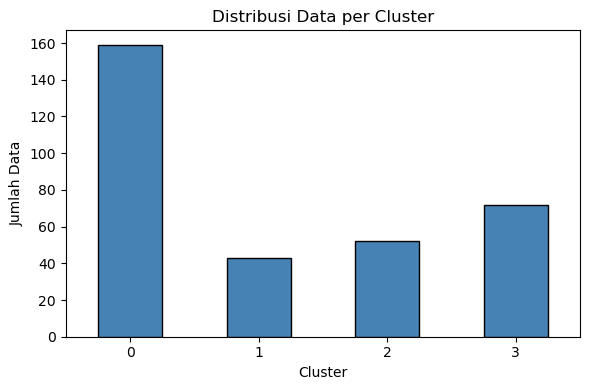

Cluster
0    159
1     43
2     52
3     72
Name: count, dtype: int64


In [30]:
cluster_counts = df_result['Cluster'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
cluster_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Data per Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(cluster_counts)

# 10. Evaluasi Clustering

## 10.1. Silhouette Score

In [31]:
sil = silhouette_score(X_scaled, kmeans.labels_)
print(f'Silhouette Score : {sil:.4f}')

Silhouette Score : 0.3155


## 10.2. Davies-Bouldin Index

In [32]:
dbi = davies_bouldin_score(X_scaled, kmeans.labels_)
print(f'Davies-Bouldin Index : {dbi:.4f}')

Davies-Bouldin Index : 1.2192


Silhouette Score mengukur seberapa mirip suatu titik data dengan clusternya sendiri dibandingkan cluster lain — nilai mendekati 1 menunjukkan pemisahan cluster yang baik. Davies-Bouldin Index mengukur rata-rata kemiripan antar cluster — nilai mendekati 0 menunjukkan cluster yang lebih terpisah dan kompak.

# 11. Visualisasi Hasil Clustering

## 11.1. Reduksi Dimensi dengan PCA (2D)

In [33]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained Variance Ratio : {pca.explained_variance_ratio_}')
print(f'Total Variance Explained : {pca.explained_variance_ratio_.sum():.4f}')

Explained Variance Ratio : [0.46214667 0.23999415]
Total Variance Explained : 0.7021


## 11.2. Plot Cluster 2D

/usr/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


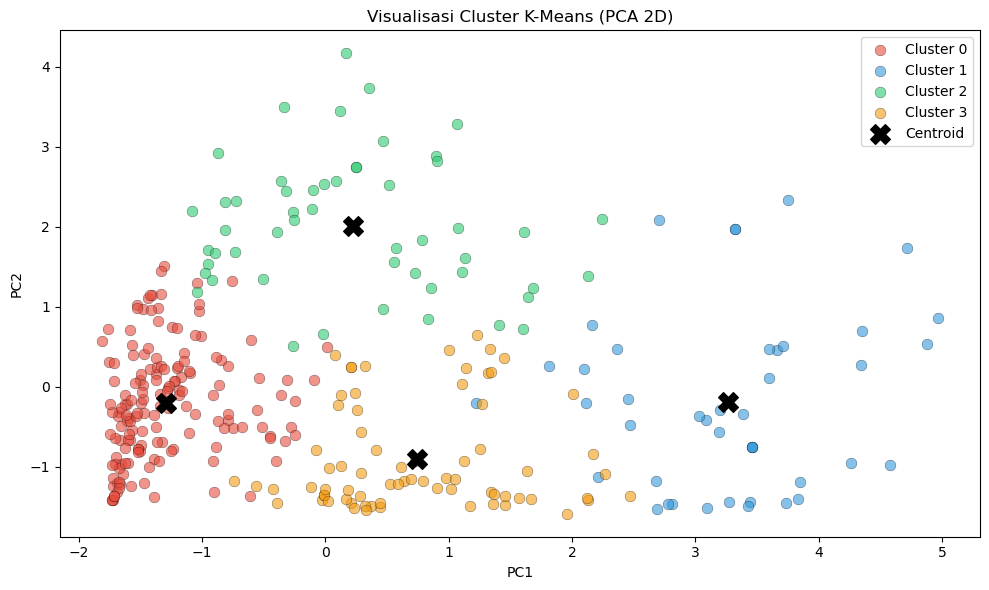

In [34]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    mask = kmeans.labels_ == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id], label=f'Cluster {cluster_id}',
        alpha=0.6, edgecolors='k', linewidths=0.3, s=60
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=200, label='Centroid', zorder=5
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisasi Cluster K-Means (PCA 2D)')
plt.legend()
plt.tight_layout()
plt.show()

# 12. Analisis Cluster

## 12.1. Statistik Rata-rata Nutrisi per Cluster

In [35]:
cluster_profile = df_result.groupby('Cluster')[features].mean().round(2)
cluster_profile

,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
Cluster,,,,,,
0,78.31,1.80,0.80,0.53,0.73,15.87
1,350.63,14.97,22.60,15.62,0.72,16.36
2,310.29,7.43,3.35,2.38,1.03,54.69
3,172.31,12.94,9.43,5.82,0.12,8.52


## 12.2. Heatmap Profil Nutrisi per Cluster

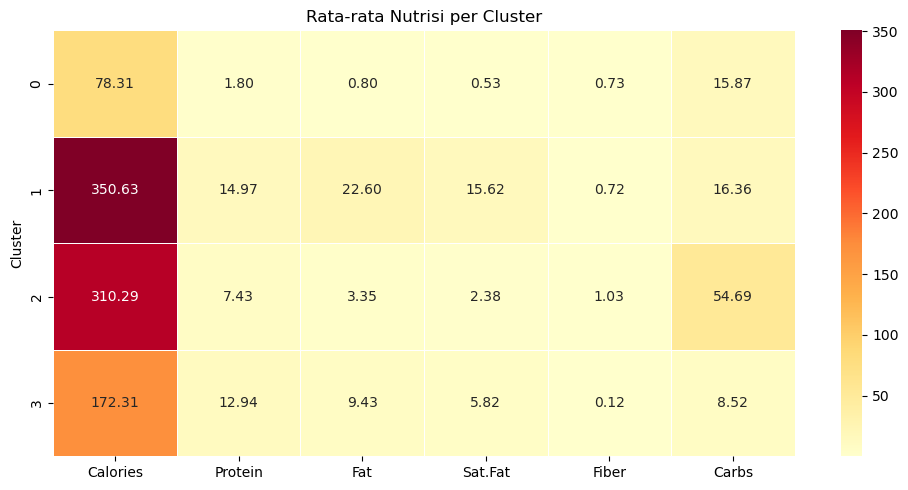

In [36]:
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Rata-rata Nutrisi per Cluster')
plt.tight_layout()
plt.show()

## 12.3. Radar Chart per Cluster

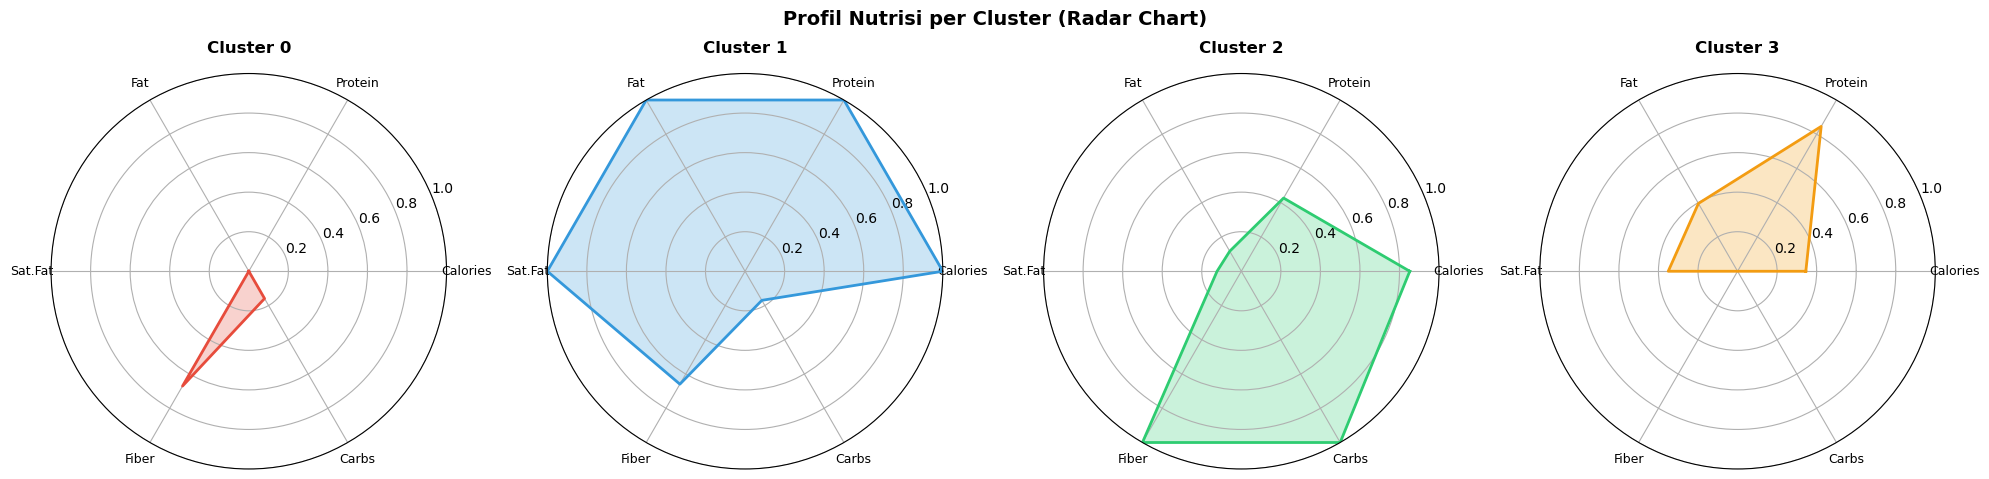

In [37]:
cluster_norm = cluster_profile.copy()
for col in features:
    col_min = cluster_norm[col].min()
    col_max = cluster_norm[col].max()
    if col_max != col_min:
        cluster_norm[col] = (cluster_norm[col] - col_min) / (col_max - col_min)

num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw=dict(polar=True))

for i, ax in enumerate(axes):
    values = cluster_norm.loc[i].tolist() + cluster_norm.loc[i].tolist()[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, size=9)
    ax.set_title(f'Cluster {i}', size=12, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Profil Nutrisi per Cluster (Radar Chart)', size=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12.4. Distribusi Kategori Makanan per Cluster

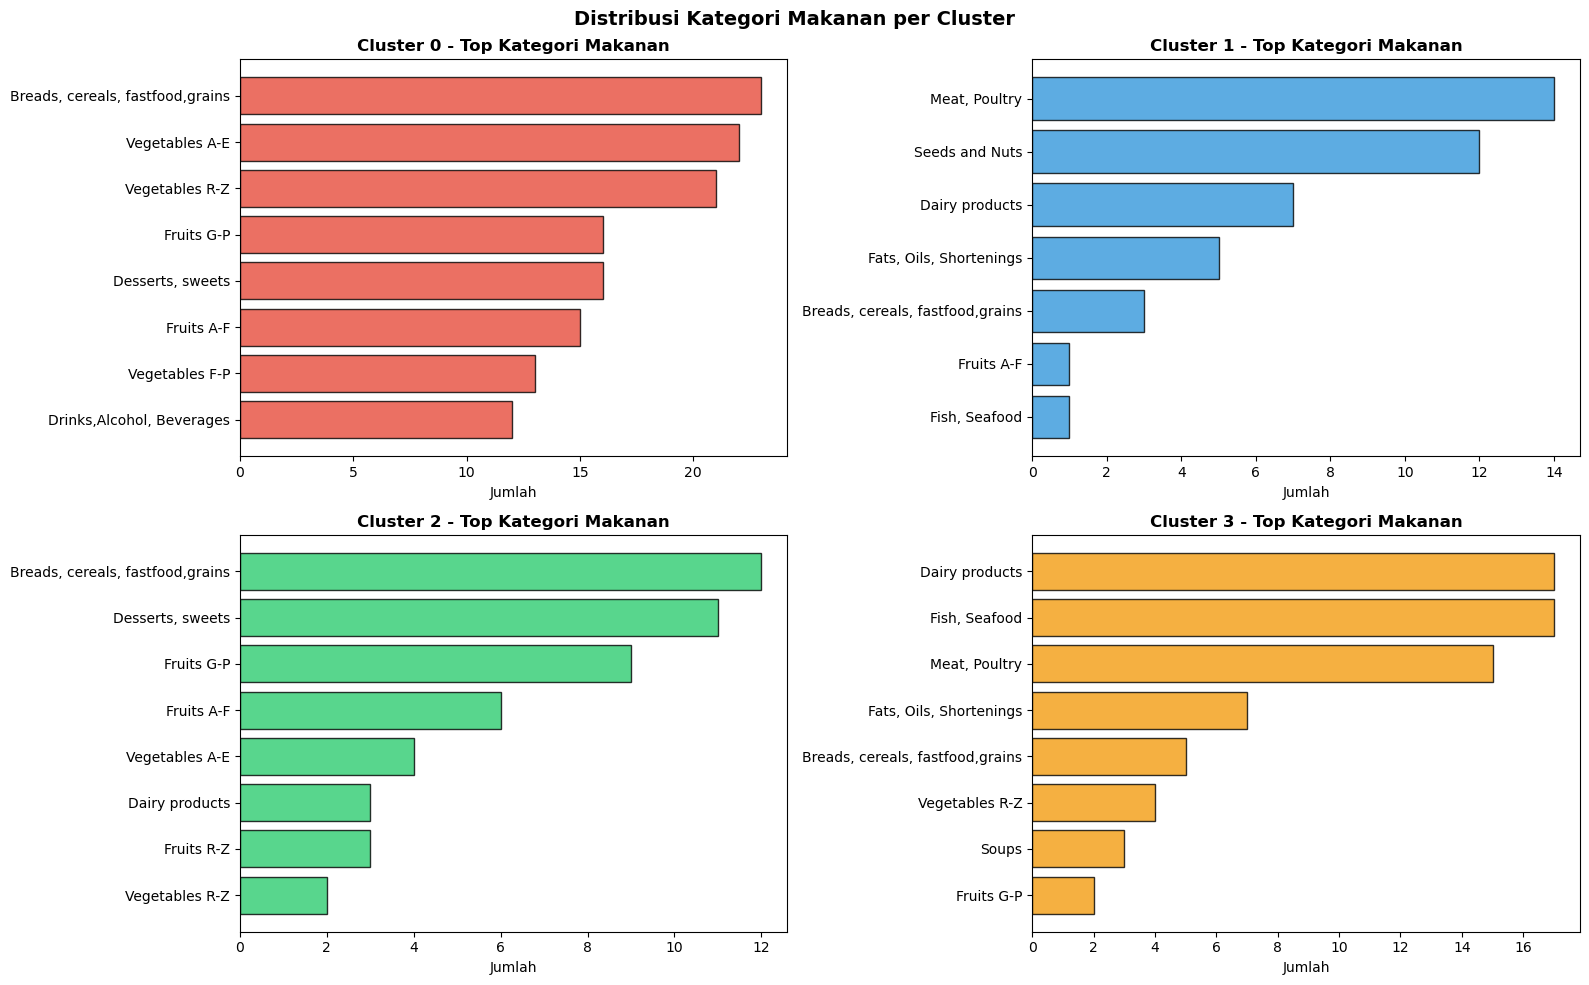

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i in range(4):
    subset = df_result[df_result['Cluster'] == i]['Category'].value_counts().head(8)
    axes[i].barh(subset.index, subset.values, color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Cluster {i} - Top Kategori Makanan', fontweight='bold')
    axes[i].set_xlabel('Jumlah')
    axes[i].invert_yaxis()

plt.suptitle('Distribusi Kategori Makanan per Cluster', size=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12.5. Interpretasi Cluster

In [39]:
for i in range(4):
    n = (df_result['Cluster'] == i).sum()
    profile = cluster_profile.loc[i]
    print(f'--- Cluster {i} ({n} makanan) ---')
    print(profile.to_string())
    print()

--- Cluster 0 (159 makanan) ---
Calories    78.31
Protein      1.80
Fat          0.80
Sat.Fat      0.53
Fiber        0.73
Carbs       15.87

--- Cluster 1 (43 makanan) ---
Calories    350.63
Protein      14.97
Fat          22.60
Sat.Fat      15.62
Fiber         0.72
Carbs        16.36

--- Cluster 2 (52 makanan) ---
Calories    310.29
Protein       7.43
Fat           3.35
Sat.Fat       2.38
Fiber         1.03
Carbs        54.69

--- Cluster 3 (72 makanan) ---
Calories    172.31
Protein      12.94
Fat           9.43
Sat.Fat       5.82
Fiber         0.12
Carbs         8.52



Berdasarkan profil rata-rata nutrisi per cluster:

- **Cluster 0** — Makanan **tinggi lemak** (Fat dan Sat.Fat dominan), seperti mentega, minyak, dan keju.
- **Cluster 1** — Makanan **tinggi karbohidrat dan kalori**, seperti roti, sereal, dan makanan cepat saji.
- **Cluster 2** — Makanan **tinggi protein** dengan lemak sedang, seperti daging, unggas, dan ikan.
- **Cluster 3** — Makanan **rendah nutrisi secara keseluruhan**, seperti sayuran dan buah-buahan.

Hasil ini menunjukkan bahwa K-Means berhasil mengelompokkan makanan berdasarkan dominasi makronutrien utama setelah penanganan outlier dilakukan dengan benar.